## Imports

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt

from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

from teleportation_circuit import create_teleportation_circuit
from fidelity_analysis import compute_fidelity

## Define Angles

In [2]:
angles = [
    0,
    np.pi/6,
    np.pi/4,
    np.pi/3,
    np.pi/2
]

## Simulator Setup

In [3]:
simulator = AerSimulator()

shots = 4096

sim_fidelities = []
sim_counts_list = []

## Run Simulator Experiments

In [4]:
for theta in angles:

    qc = create_teleportation_circuit(theta)

    transpiled = simulator.run(qc)

    results = transpiled.result()

    counts = results.get_counts()

    fidelity = compute_fidelity(counts, shots)

    sim_fidelities.append(fidelity)

    sim_counts_list.append(counts)

In [6]:
print(sim_fidelities)
print(sim_counts_list)

[0.25, 0.25, 0.25, 0.25, 0.25]
[{'001': 235, '011': 257, '010': 262, '000': 270}, {'011': 239, '000': 247, '010': 276, '001': 262}, {'001': 265, '000': 269, '010': 227, '011': 263}, {'000': 262, '010': 259, '001': 249, '011': 254}, {'001': 230, '011': 259, '010': 263, '000': 272}]


## Connect to IBM Quantum

In [10]:
service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)


print(f"Trageting Backend: {backend.name}")
print("Backend version:", backend.version)
print("Number of qubits:", backend.num_qubits)
print("Number of Pending Jobs:", backend.status().pending_jobs)

Trageting Backend: ibm_torino
Backend version: 2
Number of qubits: 133
Number of Pending Jobs: 0


## Hardware Execution

In [12]:
hardware_fidelities = []
hardware_counts_list = []

sampler = Sampler(mode=backend)

for theta in angles:

    qc = create_teleportation_circuit(theta)

    pm = generate_preset_pass_manager(backend=backend)

    isa_circuit = pm.run(qc)

    job = sampler.run([isa_circuit], shots=4096)

    result = job.result()

    counts = result[0].data.c.get_counts()

    fidelity = compute_fidelity(counts,4096)

    hardware_fidelities.append(fidelity)

    hardware_counts_list.append(counts)

## Plot Histogram Example

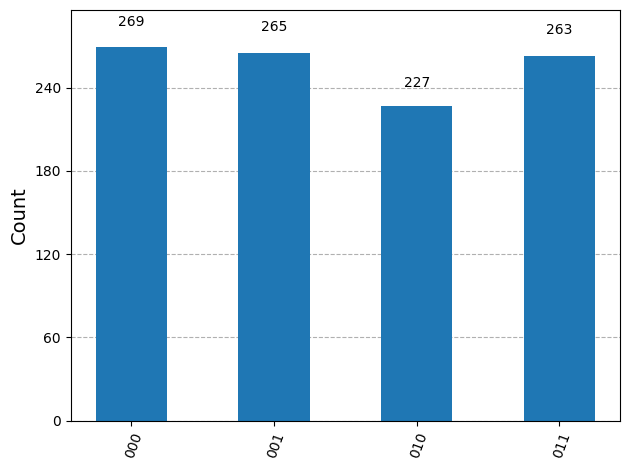

In [13]:
plot_histogram(sim_counts_list[2])

## Fidelity Plot

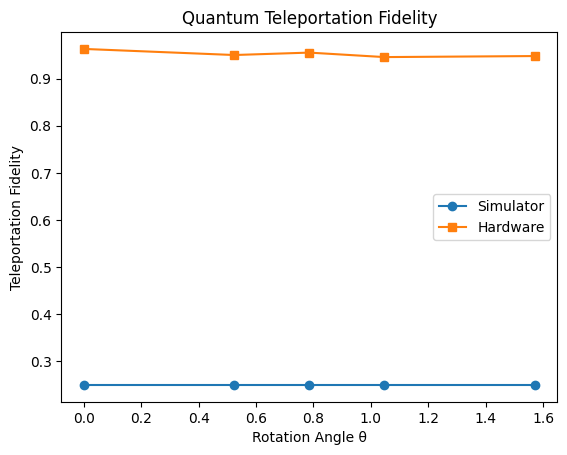

In [14]:
plt.plot(angles, sim_fidelities, marker='o', label="Simulator")
plt.plot(angles, hardware_fidelities, marker='s', label="Hardware")

plt.xlabel("Rotation Angle θ")
plt.ylabel("Teleportation Fidelity")
plt.title("Quantum Teleportation Fidelity")

plt.legend()

plt.show()

## Save Results

In [25]:
with open("results/simulator_results.json","w") as f:

    json.dump(sim_counts_list,f)


with open("results/hardware_results.json","w") as f:

    json.dump(hardware_counts_list,f)